In [1]:
import sys

import h5py
from IPython.display import HTML
from matplotlib import animation
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.constants import c as c_light
from scipy.constants import mu_0 as mu_0
from tqdm import tqdm

sys.path.append("../")

from wakis.gridFIT3D import GridFIT3D
from wakis.solverFIT3D import SolverFIT3D
from wakis.sources import Pulse

## Simulation Domain

In [2]:
Nx = 200
Ny = 20
Nz = 20

xmin, xmax, ymin, ymax, zmin, zmax = -0.125, 0.375, -0.025, 0.025, -0.025, 0.025
grid = GridFIT3D(xmin, xmax, ymin, ymax, zmin, zmax, Nx, Ny, Nz)
Nt = 530
dt = 2.5e-12

bc_low = ["cpml", "periodic", "pec"]
bc_high = ["cpml", "periodic", "pec"]

Generating grid with 80000 mesh cells...
    * Simulation domain bounds: 
                x:[-0.125, 0.375],
                y:[-0.025, 0.025],
                z:[-0.025, 0.025]
    * Minimum cell sizes: dx=2.500e-03, dy=2.500e-03, dz=2.500e-03
Importing STL solids...
Total grid initialization time: 0.013481616973876953 s


In [3]:
E_pml = []
E_pml_2d = []
frame_stride = 10
x_pml = grid.x.copy()
y_pml = grid.y.copy()

# set solver
solver = SolverFIT3D(
    grid,
    bc_low=bc_low,
    bc_high=bc_high,
    dt=dt,
    kappa_max=5,
    alpha_max=0.05,
    pml_exp=4,
    sigma_factor=1.0,
    n_pml=10,
)  # Parameters to tune CPML: kappa_max, alpha_max, pml_exp, sigma_factor, n_pml

print("Time step:", solver.dt)

# set source
source = Pulse(
    field="Ez",
    xs=50,
    ys=slice(0, Ny),
    zs=slice(0, Nz),
    shape="harris",
    L=0.15,
)

for n in tqdm(range(Nt)):
    source.update(solver, n * solver.dt)
    solver.one_step()
    E_pml.append((solver.E[20, Ny // 2, Nz // 2, "z"].copy()))
    if n % frame_stride == 0:
        E_pml_2d.append(solver.E[:, :, Nz // 2, "z"].copy())

Initializing Electromagnetic solver...
    * Maximum frequency set to fmax=1.0 GHz
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
    * Max resolved conductivity without SIBC: 202.64236731143956 S/m
Filling CPML parameters...
[!] CPML requires Total-Field/Scattered-Field injection, setting source_type='tfsf'
    * CPML thickness: 10 cells
Calculating maximal stable timestep...
    * Simulation timestep: dt=2.500e-12 s
Pre-computing...
Using MKL backend for time-stepping...
Total solver initialization time: 5.640591144561768 s
Time step: 2.5e-12


100%|██████████| 530/530 [00:02<00:00, 229.68it/s]


## Reference

In [4]:
Nx = 300
xmin = -0.375
gridRef = GridFIT3D(xmin, xmax, ymin, ymax, zmin, zmax, Nx, Ny, Nz)
bc_low_ref = ["pec", "periodic", "pec"]
bc_high_ref = ["pec", "periodic", "pec"]

E_ref = []
E_ref_2d = []
x_ref = gridRef.x.copy()
y_ref = gridRef.y.copy()

# set solver
solverRef = SolverFIT3D(gridRef, bc_low=bc_low_ref, bc_high=bc_high_ref, dt=dt)
print("Time step:", solverRef.dt)

# set source
sourceRef = Pulse(
    field="Ez",
    xs=150,
    ys=slice(0, Ny),
    zs=slice(0, Nz),
    shape="harris",
    L=0.15,
)


# ------------ Time loop ----------------

for n in tqdm(range(Nt)):
    sourceRef.update(solverRef, n * solverRef.dt)
    solverRef.one_step()
    E_ref.append((solverRef.E[120, Ny // 2, Nz // 2, "z"].copy()))
    if n % frame_stride == 0:
        E_ref_2d.append(solverRef.E[:, :, Nz // 2, "z"].copy())

Generating grid with 120000 mesh cells...
    * Simulation domain bounds: 
                x:[-0.375, 0.375],
                y:[-0.025, 0.025],
                z:[-0.025, 0.025]
    * Minimum cell sizes: dx=2.500e-03, dy=2.500e-03, dz=2.500e-03
Importing STL solids...
Total grid initialization time: 0.009745359420776367 s
Initializing Electromagnetic solver...
    * Maximum frequency set to fmax=1.0 GHz
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
    * Max resolved conductivity without SIBC: 202.64236731143956 S/m
Calculating maximal stable timestep...
    * Simulation timestep: dt=2.500e-12 s
Pre-computing...
Using MKL backend for time-stepping...
Total solver initialization time: 12.232704401016235 s
Time step: 2.5e-12


100%|██████████| 530/530 [00:01<00:00, 297.78it/s]


## Field animation

The animation compares the $E_z$ field on the central $x$-$y$ plane of the CPML simulation and the larger, boundary-distant reference domain. Frames are saved every `frame_stride` timesteps during the two time loops to keep the notebook memory use modest.

In [5]:
field_limit = max(
    np.abs(np.asarray(E_pml_2d)).max(),
    np.abs(np.asarray(E_ref_2d)).max(),
)
frames = min(len(E_pml_2d), len(E_ref_2d))

fig = plt.figure(figsize=(13, 4), layout="constrained")
grid_spec = fig.add_gridspec(1, 3, width_ratios=(1, 1, 0.04))
axes = [
    fig.add_subplot(grid_spec[0, 0]),
    fig.add_subplot(grid_spec[0, 1]),
]
axes[1].sharey(axes[0])
colorbar_axis = fig.add_subplot(grid_spec[0, 2])
images = []
for ax, field, x, y, title in (
    (axes[0], E_pml_2d[0], x_pml, y_pml, "CPML simulation domain"),
    (axes[1], E_ref_2d[0], x_ref, y_ref, "Reference domain"),
):
    image = ax.imshow(
        field.T,
        origin="lower",
        aspect="auto",
        cmap="jet",
        extent=[x[0], x[-1], y[0], y[-1]],
        vmin=-field_limit,
        vmax=field_limit,
    )
    images.append(image)
    ax.set_title(title)
    ax.set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
axes[0].axvline(x_pml[50], color="white", linestyle=":", linewidth=1)
axes[1].axvline(x_ref[150], color="white", linestyle=":", linewidth=1)
fig.colorbar(images[0], cax=colorbar_axis, label=r"$E_z$ [V/m]")
time_label = fig.suptitle("")


def update(frame):
    images[0].set_data(E_pml_2d[frame].T)
    images[1].set_data(E_ref_2d[frame].T)
    time_label.set_text(f"t = {frame * frame_stride * dt * 1e9:.3f} ns")
    return (*images, time_label)


field_animation = animation.FuncAnimation(
    fig, update, frames=frames, interval=50, blit=False
)
plt.close(fig)
HTML(field_animation.to_jshtml())

## Analysis

In [6]:
f = np.fft.fftfreq(Nt, dt)
mask = f >= 0
SRef = np.fft.fft(E_ref)
SPML = np.fft.fft(E_pml)
SDiff = SPML - SRef
Sreflec = (np.abs(SDiff) / np.abs(SRef)) ** 2

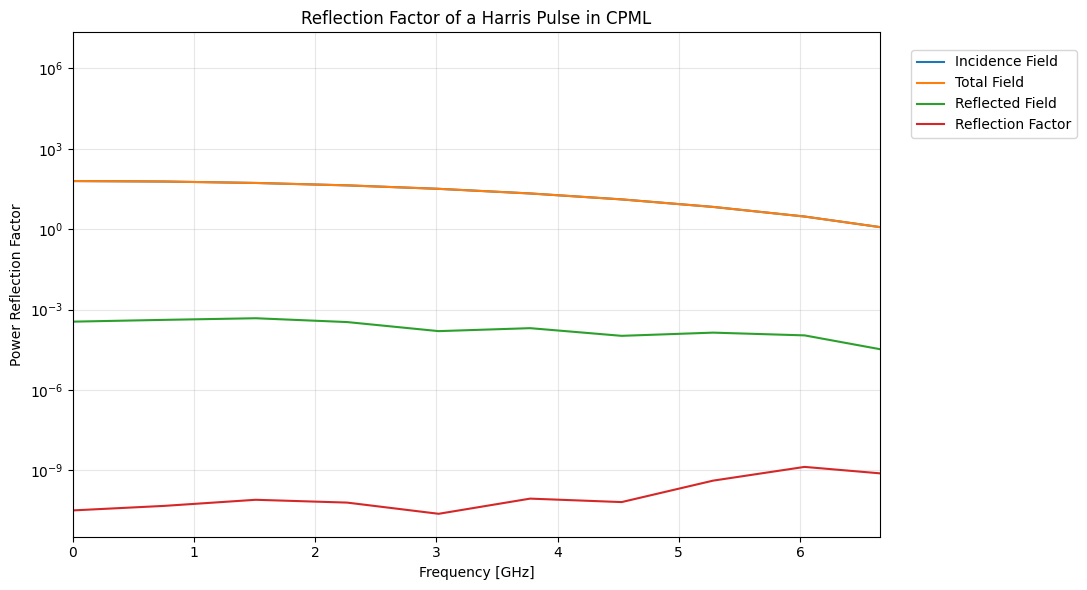

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(f[mask] * 1e-9, np.abs(SRef[mask]), label="Incidence Field")
ax.plot(f[mask] * 1e-9, np.abs(SPML[mask]), label="Total Field")
ax.plot(f[mask] * 1e-9, np.abs(SDiff[mask]), label="Reflected Field")
ax.plot(f[mask] * 1e-9, np.abs(Sreflec[mask]), label="Reflection Factor")
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Power Reflection Factor")
ax.set_xlim(0, 6.66)
ax.grid(True, which="both", axis="y", alpha=0.3)
ax.grid(True, which="both", axis="x", alpha=0.3)
ax.set_yscale("log")
ax.set_title("Reflection Factor of a Harris Pulse in CPML")

fig.legend(loc="upper left", bbox_to_anchor=(1.01, 0.92))
fig.tight_layout()
plt.show()